In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.diagnostic import linear_reset
import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
import scipy.stats as stats
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error


import sys
sys.path.append("..")

from utils.preprocessing import preprocessing_completo
from utils.config import PATH_RAD_MUNICIPIOS, PATH_PIB_MONTERREY

_,_,mont_rad_pib = preprocessing_completo("monterrey", path_radianza = PATH_RAD_MUNICIPIOS, path_pib = PATH_PIB_MONTERREY)

mont_rad_pib["log_pib_mun_trend"] = np.log(mont_rad_pib["pib_mun_trend"])
medidas = mont_rad_pib.drop(["quarter", "fecha", "municipio", "pib_mun_desestacionalizado", "pib_mun_trend", "log_pib_mun_trend"],axis = 1).columns
for col in medidas:
    mont_rad_pib[col] = np.log(mont_rad_pib[col])


# Random Forest Regressor sin 'year'

In [ ]:
X = mont_rad_pib[medidas]
y = mont_rad_pib["log_pib_mun_trend"]

rf = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10, min_samples_split=10)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

metrics = {
    "MSE": [],
    "RMSE": [],
    "MAE": [],
    "MAPE": [],
    "MSE_log": [],
    "RMSE_log": [],
    "MAE_log": [],
    "MAPE_log": []
}

for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    
    # Calcular métricas
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test))
    
    # Calcular métricas en escala logarítmica
    y_test_log = np.log(y_test)
    y_pred_log = np.log(y_pred)
    
    mse_log = mean_squared_error(y_test_log, y_pred_log)
    rmse_log = np.sqrt(mse_log)
    mae_log = mean_absolute_error(y_test_log, y_pred_log)
    mape_log = np.mean(np.abs((y_test_log - y_pred_log) / y_test_log))

    metrics["MSE"].append(mse)
    metrics["RMSE"].append(rmse)
    metrics["MAE"].append(mae)
    metrics["MAPE"].append(mape)
    metrics["MSE_log"].append(mse_log)
    metrics["RMSE_log"].append(rmse_log)
    metrics["MAE_log"].append(mae_log)
    metrics["MAPE_log"].append(mape_log)


metrics = pd.DataFrame(metrics)
metrics.agg(["mean", "std"])


,MSE,RMSE,MAE,MAPE,MSE_log,RMSE_log,MAE_log,MAPE_log
mean,0.001813,0.042119,0.033101,0.002686,0.000012,0.003418,0.002685,0.001069
std,0.000642,0.006991,0.002194,0.000176,0.000004,0.000573,0.000176,0.000070


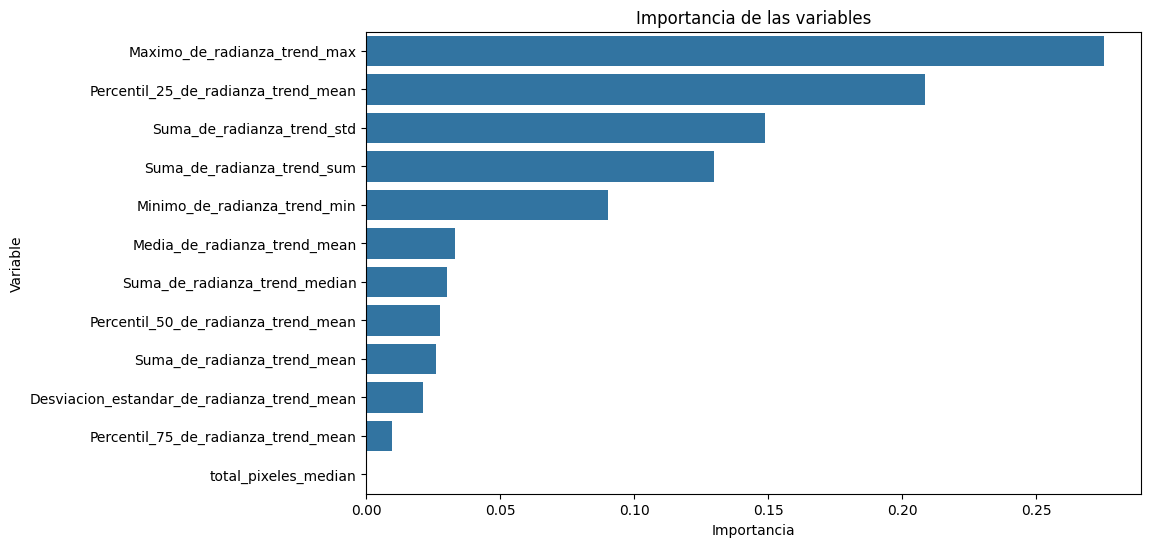

In [11]:
importance = rf.feature_importances_
feature_names = X.columns

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(by = "Importance", ascending = False)
importance = rf.feature_importances_

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=feature_importance, orient="h")
plt.title("Importancia de las variables")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()


# Random Forest Regressor con 'Year'